# Network Analysis — AI Coding Assistant Trust & Distrust
**COSC 3047 Assignment 2**

This notebook constructs and analyses a directed user interaction network from social media comments about AI coding assistants.

**Network definition:**
- **Nodes** — unique users (commenters)
- **Edges** — directed reply relationships (user A replied to user B)
- **Edge weight** — number of times A replied to B

**Analyses performed:**
1. Graph construction from reply edges (YouTube + HN)
2. Basic network statistics (density, components, degree distribution)
3. Centrality analysis (PageRank, in-degree, betweenness) — identifying influential users
4. Community detection (Louvain) — finding discussion clusters using all edge types
5. Cross-analysis — linking network position to sentiment and topic labels

**Input:** `data/processed/combined/combined_edges.json`, `data/processed/nlp/comments_with_topics.csv`
**Output:** `data/processed/network/`

## 1. Setup & Imports

In [31]:
import json
import logging
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns
from community import community_louvain

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger(__name__)

In [32]:
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / ".git").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / "data/processed/network"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EDGES_PATH = PROJECT_ROOT / "data/processed/combined/combined_edges.json"
NLP_PATH   = PROJECT_ROOT / "data/processed/nlp/comments_with_topics.csv"

print(f"Project root:  {PROJECT_ROOT}")
print(f"Edges path:    {EDGES_PATH.exists()}")
print(f"NLP data:      {NLP_PATH.exists()}")

Project root:  /Users/gayathwethmin/Downloads/social_media_2
Edges path:    True
NLP data:      True


## 2. Colour Maps

In [33]:
SENTIMENT_COLORS = {
    "positive": "#4CAF50",
    "neutral":  "#FF9800",
    "negative": "#F44336",
    "unknown":  "#9E9E9E"
}

TOPIC_COLORS = {
    "productivity":    "#2196F3",
    "reliability":     "#F44336",
    "security":        "#FF9800",
    "cost":            "#9C27B0",
    "code_ownership":  "#009688",
    "job_displacement":"#795548",
    "other":           "#9E9E9E",
    "unknown":         "#BDBDBD"
}

print("Colour maps defined.")

Colour maps defined.


## 3. Load Edge Data

The combined edge file contains four types of edges:
- `reply` (YouTube + HN) — directed user→user reply relationships
- `user_thread` (HN + GitHub) — bipartite user→thread participation

For the **directed graph** (PageRank, centrality) we use `reply` edges only.
For **community detection** (Louvain) we use all edges for richer structure.
Issue key nodes (containing `#`) are filtered out — they are thread IDs not users.

In [34]:
with open(EDGES_PATH, encoding="utf-8") as f:
    raw_edges = json.load(f)

edges_df = pd.DataFrame(raw_edges)
log.info(f"Loaded {len(edges_df):,} total edges")

# Filter out issue key nodes (contain '#') — these are thread IDs not users
edges_df = edges_df[~edges_df["source"].str.contains("#", na=False)]
edges_df = edges_df[~edges_df["target"].str.contains("#", na=False)]

# Remove self-loops
edges_df = edges_df[edges_df["source"] != edges_df["target"]]

# Remove empty authors
edges_df = edges_df[edges_df["source"].str.strip().str.len() > 0]
edges_df = edges_df[edges_df["target"].str.strip().str.len() > 0]

# Reply edges only for directed graph
reply_df = edges_df[edges_df["edge_type"] == "reply"].copy()
reply_df = (
    reply_df
    .groupby(["source", "target", "platform"])
    .agg(weight=("weight", "sum"))
    .reset_index()
)

print(f"Total edges after filtering: {len(edges_df):,}")
print(f"Reply edges (directed graph): {len(reply_df):,}")
print(f"Edge types: {edges_df['edge_type'].value_counts().to_dict()}")
print(f"Platforms:  {edges_df['platform'].value_counts().to_dict()}")
reply_df.head(3)

21:12:21 [INFO] Loaded 14,128 total edges


Total edges after filtering: 7,838
Reply edges (directed graph): 4,766
Edge types: {'reply': 4769, 'user_thread': 3069}
Platforms:  {'youtube': 4747, 'hackernews': 3091}


,source,target,platform,weight
0,1123581321,enono,hackernews,1
1,@-Engineering01-,@SomeRandomUserOFYT,youtube,1
2,@-Engineering01-,@abyrvalg809,youtube,1


## 4. Load NLP Data

Sentiment scores and topic labels are loaded and aggregated per user.
These are attached as node attributes to enable cross-analysis with network position.

In [35]:
nlp_df = pd.read_csv(NLP_PATH)

# Map column names — handle both YouTube-only and combined NLP outputs
author_col = "commentAuthor" if "commentAuthor" in nlp_df.columns else "author"
text_col   = "commentText"   if "commentText"   in nlp_df.columns else "text"
likes_col  = "commentLikeCount" if "commentLikeCount" in nlp_df.columns else "like_count"

user_profiles = (
    nlp_df.groupby(author_col)
    .agg(
        avg_sentiment=("sentiment_compound", "mean"),
        comment_count=(text_col, "count"),
        dominant_topic=("topic_label", lambda x: x.value_counts().index[0] if len(x) > 0 else "unknown"),
        total_likes=(likes_col, "sum")
    )
    .reset_index()
    .rename(columns={author_col: "author"})
)
user_profiles["sentiment_label"] = user_profiles["avg_sentiment"].apply(
    lambda x: "positive" if x >= 0.05 else "negative" if x <= -0.05 else "neutral"
)

user_dict = user_profiles.set_index("author").to_dict(orient="index")

print(f"User profiles: {len(user_profiles):,} unique users")
print(f"Sentiment distribution:")
print(user_profiles["sentiment_label"].value_counts().to_string())
user_profiles.head(3)

/var/folders/ky/frwppj2d4wq6ld_d8gktf7x40000gn/T/ipykernel_4379/3722831112.py:1: DtypeWarning: Columns (5,8) have mixed types. Specify dtype option on import or set low_memory=False.
  nlp_df = pd.read_csv(NLP_PATH)


User profiles: 25,630 unique users
Sentiment distribution:
sentiment_label
positive    14582
neutral      5770
negative     5278


,author,avg_sentiment,comment_count,dominant_topic,total_likes,sentiment_label
0,0-BlackSpectrum-0,0.7959,1,productivity,0,positive
1,0-_-0,-0.7102,1,productivity,0,negative
2,0-bad-sectors,-0.2263,1,productivity,0,negative


## 5. Graph Construction

A directed weighted graph is built from reply edges only.
- **Directed** — a reply from A to B does not imply B replied to A
- **Weighted** — edge weight = number of times A replied to B

NLP attributes are attached to each node for cross-analysis.

In [36]:
G = nx.DiGraph()

for _, row in reply_df.iterrows():
    G.add_edge(row["source"], row["target"],
               weight=row["weight"], platform=row["platform"])

# Attach NLP attributes to nodes
for node in G.nodes():
    if node in user_dict:
        for attr, val in user_dict[node].items():
            G.nodes[node][attr] = val
    else:
        G.nodes[node]["avg_sentiment"]  = 0.0
        G.nodes[node]["sentiment_label"] = "unknown"
        G.nodes[node]["dominant_topic"]  = "unknown"
        G.nodes[node]["comment_count"]   = 0
        G.nodes[node]["total_likes"]     = 0

print(f"Graph constructed:")
print(f"  Nodes (users):    {G.number_of_nodes():,}")
print(f"  Edges (replies):  {G.number_of_edges():,}")
print(f"  Density:          {nx.density(G):.6f}")
print(f"  Is DAG:           {nx.is_directed_acyclic_graph(G)}")

Graph constructed:
  Nodes (users):    5,650
  Edges (replies):  4,766
  Density:          0.000149
  Is DAG:           False


## 6. Basic Network Statistics

Degree distribution reveals whether the network follows a power law — typical of social networks where a few users attract most replies.

In [38]:
G_undirected = G.to_undirected()
components   = list(nx.connected_components(G_undirected))
largest_cc   = max(components, key=len)

in_degrees  = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print(f"Connected components:       {len(components):,}")
print(f"Largest component:          {len(largest_cc):,} nodes ({len(largest_cc)/G.number_of_nodes()*100:.1f}%)")
print(f"Isolated nodes:             {sum(1 for c in components if len(c) == 1):,}")
print()
print(f"In-degree  — max: {max(in_degrees.values())}, mean: {np.mean(list(in_degrees.values())):.2f}")
print(f"Out-degree — max: {max(out_degrees.values())}, mean: {np.mean(list(out_degrees.values())):.2f}")
print()
print("Top 5 most replied-to users:")
for user, deg in sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:5]:
    s = G.nodes[user].get("sentiment_label", "unknown")
    t = G.nodes[user].get("dominant_topic", "unknown")
    print(f"  {user[:40]:40s} in-degree: {deg:4d} | {s} | {t}")

Connected components:       964
Largest component:          1,229 nodes (21.8%)
Isolated nodes:             0

In-degree  — max: 71, mean: 0.84
Out-degree — max: 162, mean: 0.84

Top 5 most replied-to users:
  @JeffSu                                  in-degree:   71 | positive | productivity
  @devforgehq                              in-degree:   67 | positive | productivity
  @jamesp9304                              in-degree:   50 | negative | productivity
  @Fireship                                in-degree:   49 | positive | productivity
  @_Digital_Dreams_                        in-degree:   30 | neutral | reliability


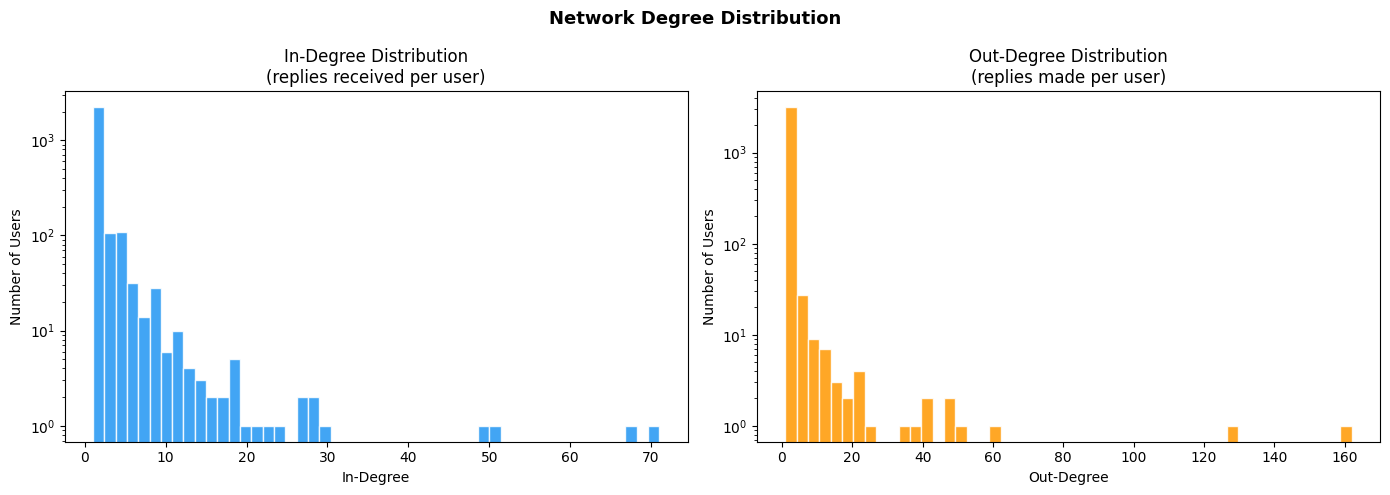

Saved degree_distribution.png


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Network Degree Distribution", fontsize=13, fontweight="bold")

in_deg_vals  = [d for _, d in G.in_degree()  if d > 0]
out_deg_vals = [d for _, d in G.out_degree() if d > 0]

axes[0].hist(in_deg_vals,  bins=50, color="#2196F3", edgecolor="white", alpha=0.85)
axes[0].set_title("In-Degree Distribution\n(replies received per user)")
axes[0].set_xlabel("In-Degree")
axes[0].set_ylabel("Number of Users")
axes[0].set_yscale("log")

axes[1].hist(out_deg_vals, bins=50, color="#FF9800", edgecolor="white", alpha=0.85)
axes[1].set_title("Out-Degree Distribution\n(replies made per user)")
axes[1].set_xlabel("Out-Degree")
axes[1].set_ylabel("Number of Users")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "degree_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved degree_distribution.png")

## 7. Centrality Analysis

Three centrality measures identify influential users:
- **PageRank** — overall influence accounting for quality of connections
- **In-degree centrality** — proportion of users who directly reply to this user
- **Betweenness centrality** — how often a user bridges two other users

Cross-referencing with sentiment and topic directly answers the research question: *do influential users shape trust or distrust?*

In [40]:
log.info("Computing PageRank...")
pagerank = nx.pagerank(G, weight="weight", alpha=0.85)

log.info("Computing in-degree centrality...")
in_degree_centrality = nx.in_degree_centrality(G)

log.info("Computing betweenness centrality (largest component)...")
G_lcc        = G.subgraph(largest_cc).copy()
betweenness  = nx.betweenness_centrality(G_lcc, weight="weight", normalized=True)

centrality_df = pd.DataFrame({
    "user":                 list(pagerank.keys()),
    "pagerank":             list(pagerank.values()),
    "in_degree_centrality": [in_degree_centrality.get(u, 0) for u in pagerank],
    "betweenness":          [betweenness.get(u, 0)           for u in pagerank],
    "in_degree":            [in_degrees.get(u, 0)            for u in pagerank],
    "out_degree":           [out_degrees.get(u, 0)           for u in pagerank],
    "sentiment_label":      [G.nodes[u].get("sentiment_label", "unknown") for u in pagerank],
    "dominant_topic":       [G.nodes[u].get("dominant_topic",  "unknown") for u in pagerank],
    "avg_sentiment":        [G.nodes[u].get("avg_sentiment",   0.0)       for u in pagerank],
    "total_likes":          [G.nodes[u].get("total_likes",     0)         for u in pagerank],
})

centrality_df = centrality_df.sort_values("pagerank", ascending=False).reset_index(drop=True)
centrality_df.to_csv(OUTPUT_DIR / "centrality_scores.csv", index=False)

print("Top 15 most influential users (PageRank):")
print(centrality_df[["user", "pagerank", "in_degree", "sentiment_label", "dominant_topic"]].head(15).to_string(index=False))

21:12:46 [INFO] Computing PageRank...
21:12:46 [INFO] Computing in-degree centrality...


21:12:46 [INFO] Computing betweenness centrality (largest component)...


Top 15 most influential users (PageRank):
                     user  pagerank  in_degree sentiment_label dominant_topic
                  @JeffSu  0.007074         71        positive   productivity
              @devforgehq  0.006740         67        positive   productivity
              @jamesp9304  0.004939         50        negative   productivity
                @Fireship  0.004825         49        positive   productivity
               @saumay-z1  0.002926         28         neutral   productivity
        @_Digital_Dreams_  0.002876         30         neutral    reliability
              @Developete  0.002831         27        positive   productivity
           @AuroraMarinii  0.002687         27        negative    reliability
         @EhteshamShahzad  0.002592         28         neutral    reliability
          @dougsholly9323  0.002534         22        negative   productivity
          @taylorgledhill  0.002405         24         neutral   productivity
@AnonymousAnonymous-nr

### Centrality Visualisations

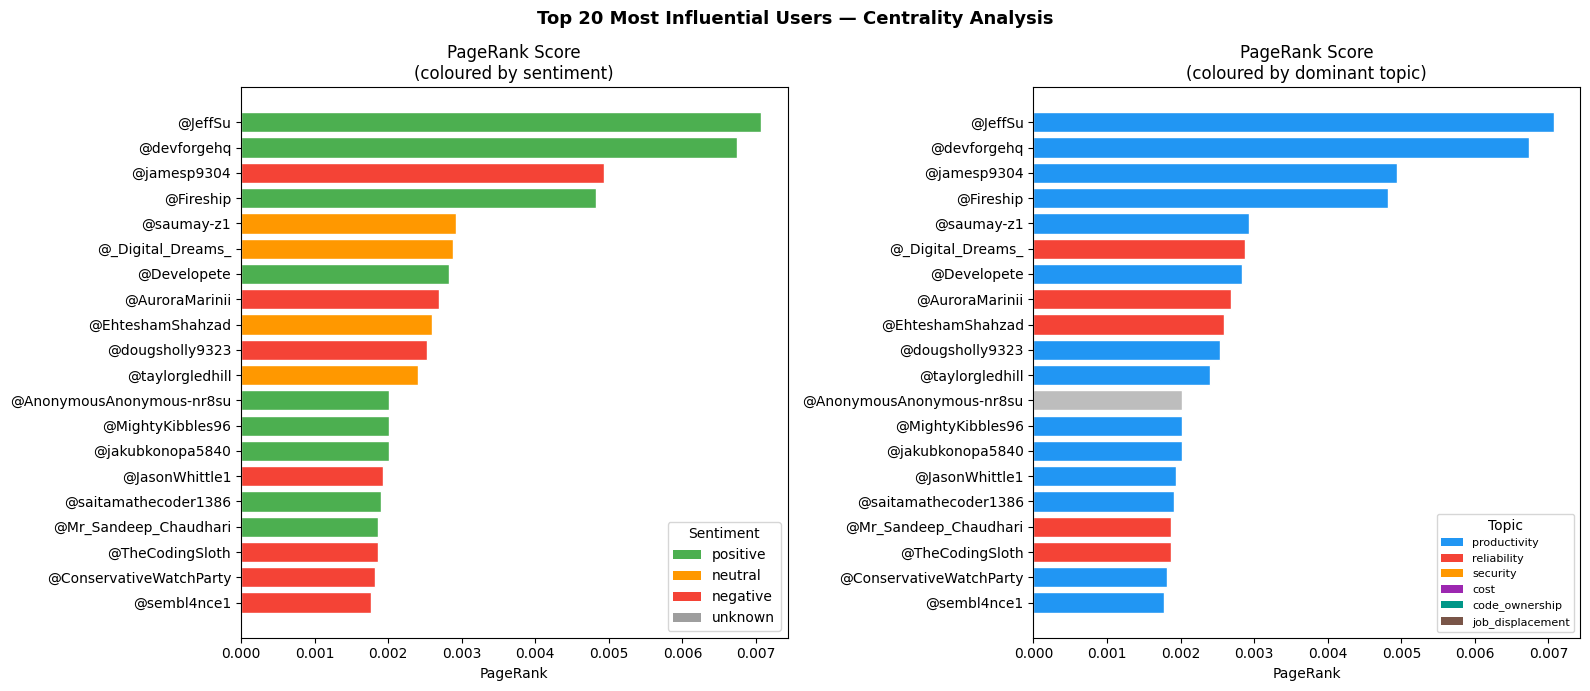

Saved top_users_centrality.png


In [41]:
top20 = centrality_df.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Top 20 Most Influential Users — Centrality Analysis", fontsize=13, fontweight="bold")

# Plot 1 — PageRank coloured by sentiment
bar_colors = [SENTIMENT_COLORS.get(s, "#9E9E9E") for s in top20["sentiment_label"]]
axes[0].barh(top20["user"].str[:30][::-1], top20["pagerank"][::-1],
             color=bar_colors[::-1], edgecolor="white")
axes[0].set_title("PageRank Score\n(coloured by sentiment)")
axes[0].set_xlabel("PageRank")
legend_elements = [Patch(facecolor=v, label=k) for k, v in SENTIMENT_COLORS.items()]
axes[0].legend(handles=legend_elements, title="Sentiment", loc="lower right")

# Plot 2 — PageRank coloured by topic
bar_colors2 = [TOPIC_COLORS.get(t, "#9E9E9E") for t in top20["dominant_topic"]]
axes[1].barh(top20["user"].str[:30][::-1], top20["pagerank"][::-1],
             color=bar_colors2[::-1], edgecolor="white")
axes[1].set_title("PageRank Score\n(coloured by dominant topic)")
axes[1].set_xlabel("PageRank")
legend_elements2 = [Patch(facecolor=v, label=k) for k, v in TOPIC_COLORS.items() if k not in ["other", "unknown"]]
axes[1].legend(handles=legend_elements2, title="Topic", loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_users_centrality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved top_users_centrality.png")

## 8. Community Detection (Louvain)

Louvain maximises modularity to find communities of users who interact more with each other than with the rest of the network.

Community detection runs on an **undirected graph using all edge types** (reply + user_thread) — this gives richer community structure than reply edges alone, incorporating HN and GitHub participation patterns.

Each community is profiled by dominant sentiment and topic to reveal whether clusters form around trust or distrust.

In [42]:
# Build undirected graph from all edge types for Louvain
G_community = nx.Graph()
for _, row in edges_df.iterrows():
    G_community.add_edge(row["source"], row["target"], weight=row.get("weight", 1))

log.info("Running Louvain community detection...")
partition = community_louvain.best_partition(G_community, weight="weight", random_state=42)

# Attach community labels to directed graph nodes
nx.set_node_attributes(G, partition, "community")

num_communities = len(set(partition.values()))
modularity = community_louvain.modularity(partition, G_community)
print(f"Communities detected: {num_communities}")
print(f"Modularity: {modularity:.4f}")
print()

# Build community profiles
community_data = []
for comm_id in sorted(set(partition.values())):
    members = [u for u, c in partition.items() if c == comm_id]
    sentiments      = []
    topics_list     = []
    sentiment_scores = []

    for u in members:
        profile = user_dict.get(u)
        if profile and profile.get("sentiment_label", "unknown") != "unknown":
            sentiments.append(profile["sentiment_label"])
            topics_list.append(profile.get("dominant_topic", "unknown"))
            sentiment_scores.append(profile.get("avg_sentiment", 0))
        elif u in G.nodes and G.nodes[u].get("sentiment_label", "unknown") != "unknown":
            sentiments.append(G.nodes[u]["sentiment_label"])
            topics_list.append(G.nodes[u].get("dominant_topic", "unknown"))
            sentiment_scores.append(G.nodes[u].get("avg_sentiment", 0))

    avg_sent           = np.mean(sentiment_scores) if sentiment_scores else 0.0
    dominant_sentiment = Counter(sentiments).most_common(1)[0][0]  if sentiments  else "unknown"
    dominant_topic     = Counter(topics_list).most_common(1)[0][0] if topics_list else "unknown"

    community_data.append({
        "community_id":        comm_id,
        "size":                len(members),
        "dominant_sentiment":  dominant_sentiment,
        "dominant_topic":      dominant_topic,
        "avg_sentiment_score": round(float(avg_sent), 4),
        "positive_pct":        round(sentiments.count("positive") / len(sentiments) * 100, 1) if sentiments else 0,
        "negative_pct":        round(sentiments.count("negative") / len(sentiments) * 100, 1) if sentiments else 0,
    })

community_df = pd.DataFrame(community_data).sort_values("size", ascending=False)
community_df.to_csv(OUTPUT_DIR / "community_profiles.csv", index=False)

print("Community profiles (top 10 by size):")
print(community_df.head(10).to_string(index=False))

21:12:54 [INFO] Running Louvain community detection...


Communities detected: 1048
Modularity: 0.9554

Community profiles (top 10 by size):
 community_id  size dominant_sentiment dominant_topic  avg_sentiment_score  positive_pct  negative_pct
          989   325            unknown        unknown               0.0000           0.0           0.0
          996   224            unknown        unknown               0.0000           0.0           0.0
           62   204           positive   productivity               0.4933          76.5           5.4
          993   204            unknown        unknown               0.0000           0.0           0.0
          991   187            unknown        unknown               0.0000           0.0           0.0
          128   181           positive   productivity               0.4481          77.2           7.8
          990   177            unknown        unknown               0.0000           0.0           0.0
          992   164            unknown        unknown               0.0000           0.0    

### Community Visualisations

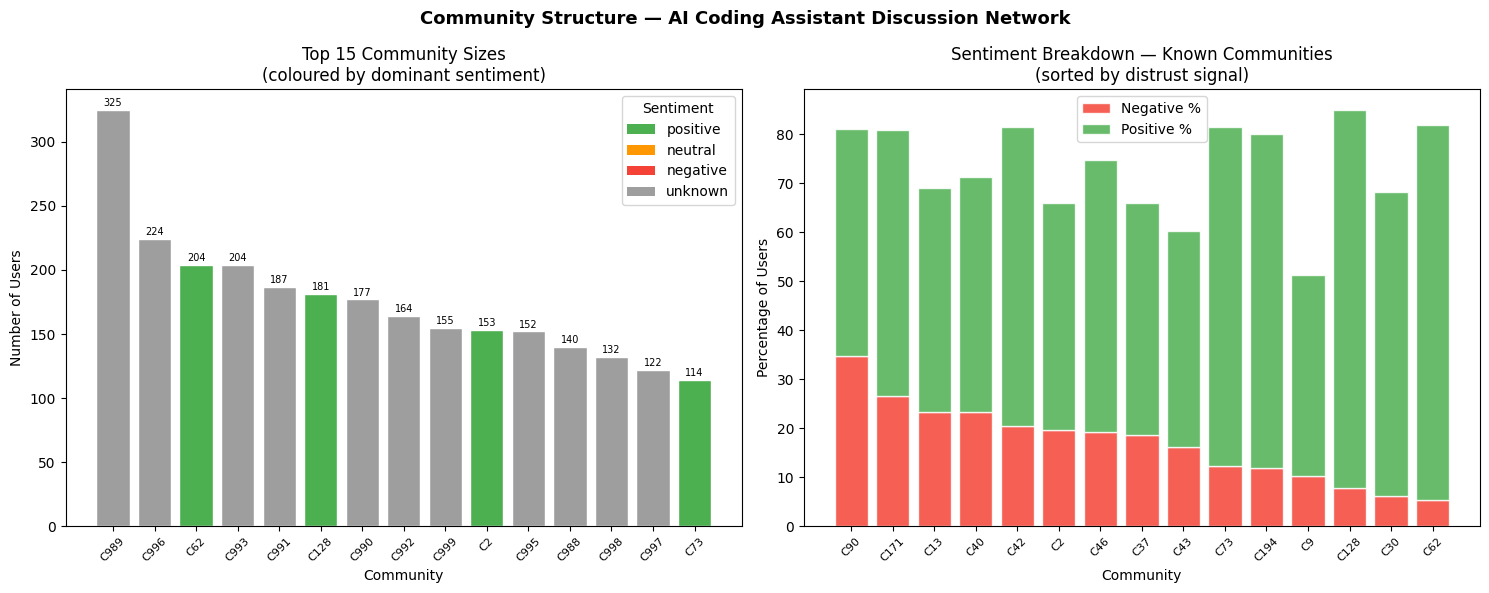

Saved community_profiles.png


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Community Structure — AI Coding Assistant Discussion Network", fontsize=13, fontweight="bold")

all_top = community_df.head(15)
known   = community_df[community_df["dominant_sentiment"] != "unknown"].head(15).sort_values("negative_pct", ascending=False)

# Plot 1 — Top 15 community sizes coloured by dominant sentiment
bar_colors = [SENTIMENT_COLORS.get(s, "#9E9E9E") for s in all_top["dominant_sentiment"]]
axes[0].bar(range(len(all_top)), all_top["size"], color=bar_colors, edgecolor="white")
axes[0].set_xticks(range(len(all_top)))
axes[0].set_xticklabels([f"C{cid}" for cid in all_top["community_id"]], rotation=45, fontsize=8)
axes[0].set_title("Top 15 Community Sizes\n(coloured by dominant sentiment)")
axes[0].set_xlabel("Community")
axes[0].set_ylabel("Number of Users")
legend_elements = [Patch(facecolor=v, label=k) for k, v in SENTIMENT_COLORS.items()]
axes[0].legend(handles=legend_elements, title="Sentiment")
for i, v in enumerate(all_top["size"]):
    axes[0].text(i, v + 3, str(v), ha="center", fontsize=7)

# Plot 2 — Sentiment breakdown for known communities (sorted by distrust)
if len(known) > 0:
    x = range(len(known))
    axes[1].bar(x, known["negative_pct"],
                color="#F44336", edgecolor="white", alpha=0.85, label="Negative %")
    axes[1].bar(x, known["positive_pct"],
                color="#4CAF50", edgecolor="white", alpha=0.85,
                bottom=known["negative_pct"].values, label="Positive %")
    axes[1].set_xticks(range(len(known)))
    axes[1].set_xticklabels([f"C{cid}" for cid in known["community_id"]], rotation=45, fontsize=8)
    axes[1].set_title("Sentiment Breakdown — Known Communities\n(sorted by distrust signal)")
    axes[1].set_xlabel("Community")
    axes[1].set_ylabel("Percentage of Users")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5,
                 "Rerun text_analysis.ipynb\non combined_comments.csv\nto populate sentiment data",
                 ha="center", va="center", transform=axes[1].transAxes,
                 fontsize=11, color="gray")
    axes[1].set_title("Sentiment Breakdown per Community")
    axes[1].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "community_profiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved community_profiles.png")

## 9. Network Visualisation

Top 150 users by PageRank are visualised. Node colour = community. Node size = PageRank score. Edge thickness = interaction weight.

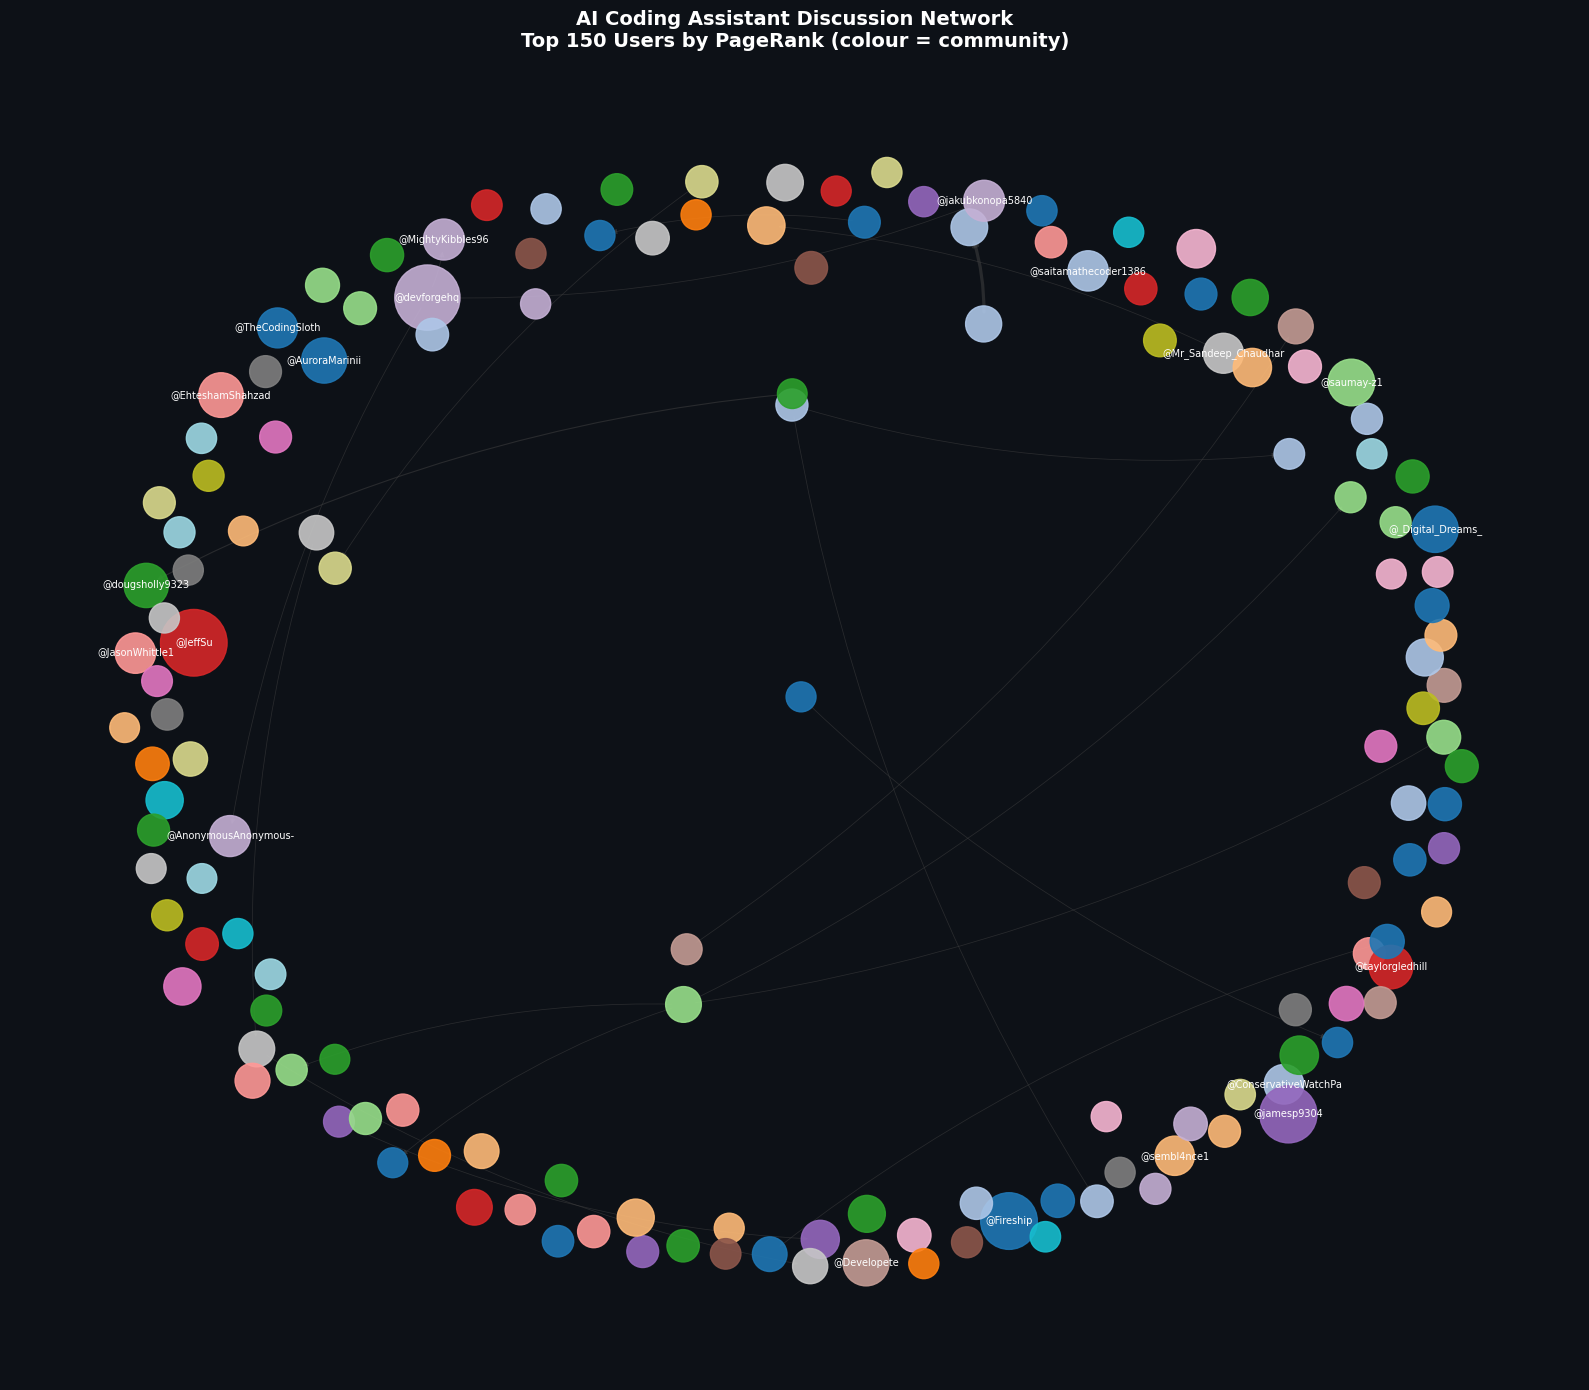

Saved network_graph.png


In [44]:
top_nodes = centrality_df.head(150)["user"].tolist()
G_sub     = G.subgraph(top_nodes).copy()

unique_communities = list(set(partition.get(n, -1) for n in G_sub.nodes()))
cmap = plt.colormaps.get_cmap("tab20").resampled(len(unique_communities))
comm_color_map = {c: mcolors.to_hex(cmap(i)) for i, c in enumerate(unique_communities)}
node_colors  = [comm_color_map.get(partition.get(n, -1), "#9E9E9E") for n in G_sub.nodes()]

pr_vals      = [pagerank.get(n, 0) for n in G_sub.nodes()]
max_pr       = max(pr_vals) if pr_vals else 1
node_sizes   = [300 + (v / max_pr) * 2000 for v in pr_vals]

edge_weights = [G_sub[u][v].get("weight", 1) for u, v in G_sub.edges()]
max_w        = max(edge_weights) if edge_weights else 1
edge_widths  = [0.3 + (w / max_w) * 2 for w in edge_weights]

fig, ax = plt.subplots(figsize=(16, 14))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")

pos = nx.spring_layout(G_sub, k=0.8, seed=42, iterations=50)

nx.draw_networkx_edges(G_sub, pos, ax=ax,
    edge_color="#444444", width=edge_widths, alpha=0.5,
    arrows=True, arrowsize=8, connectionstyle="arc3,rad=0.1")

nx.draw_networkx_nodes(G_sub, pos, ax=ax,
    node_color=node_colors, node_size=node_sizes, alpha=0.9)

top20_labels = {n: n[:20] for n in centrality_df.head(20)["user"].tolist() if n in G_sub.nodes()}
nx.draw_networkx_labels(G_sub, pos, labels=top20_labels, ax=ax,
    font_size=7, font_color="white")

ax.set_title("AI Coding Assistant Discussion Network\nTop 150 Users by PageRank (colour = community)",
             fontsize=14, fontweight="bold", color="white", pad=15)
ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "network_graph.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("Saved network_graph.png")

## 10. Synthesis — Network Position × Sentiment × Topic

This directly answers the research question: *How do influential users and communities shape concerns around trust and distrust in AI coding assistants?*

- Do high-PageRank users lean positive or negative?
- Which concern themes attract the most engagement?
- Is there a relationship between network centrality and sentiment?

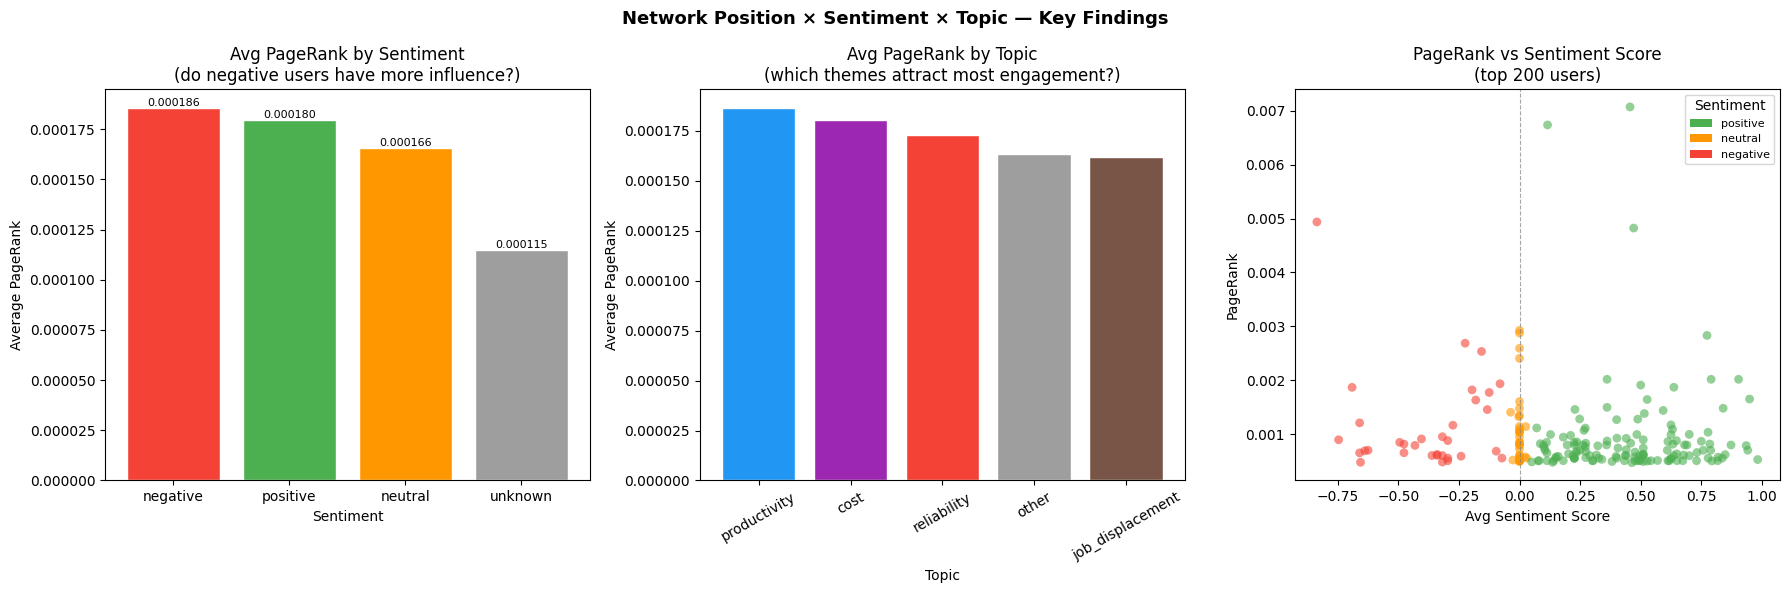

Saved synthesis_network_nlp.png


In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Network Position × Sentiment × Topic — Key Findings", fontsize=13, fontweight="bold")

# Plot 1 — Avg PageRank by sentiment
pr_by_sentiment = centrality_df.groupby("sentiment_label")["pagerank"].mean().sort_values(ascending=False)
bar_colors = [SENTIMENT_COLORS.get(s, "#9E9E9E") for s in pr_by_sentiment.index]
axes[0].bar(pr_by_sentiment.index, pr_by_sentiment.values, color=bar_colors, edgecolor="white")
axes[0].set_title("Avg PageRank by Sentiment\n(do negative users have more influence?)")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Average PageRank")
for i, v in enumerate(pr_by_sentiment.values):
    axes[0].text(i, v + 0.000001, f"{v:.6f}", ha="center", fontsize=8)

# Plot 2 — Avg PageRank by topic (exclude unknown)
pr_by_topic = centrality_df[centrality_df["dominant_topic"] != "unknown"].groupby("dominant_topic")["pagerank"].mean().sort_values(ascending=False)
bar_colors2 = [TOPIC_COLORS.get(t, "#9E9E9E") for t in pr_by_topic.index]
axes[1].bar(pr_by_topic.index, pr_by_topic.values, color=bar_colors2, edgecolor="white")
axes[1].set_title("Avg PageRank by Topic\n(which themes attract most engagement?)")
axes[1].set_xlabel("Topic")
axes[1].set_ylabel("Average PageRank")
axes[1].tick_params(axis="x", rotation=30)

# Plot 3 — Scatter: PageRank vs sentiment score (top 200 known users)
plot_df = centrality_df[centrality_df["sentiment_label"] != "unknown"].head(200)
scatter_colors = [SENTIMENT_COLORS.get(s, "#9E9E9E") for s in plot_df["sentiment_label"]]
axes[2].scatter(plot_df["avg_sentiment"], plot_df["pagerank"],
                c=scatter_colors, alpha=0.6, s=40, edgecolors="none")
axes[2].axvline(x=0, color="grey", linewidth=0.8, linestyle="--", alpha=0.7)
axes[2].set_title("PageRank vs Sentiment Score\n(top 200 users)")
axes[2].set_xlabel("Avg Sentiment Score")
axes[2].set_ylabel("PageRank")
legend_elements = [Patch(facecolor=v, label=k) for k, v in SENTIMENT_COLORS.items() if k != "unknown"]
axes[2].legend(handles=legend_elements, title="Sentiment", fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "synthesis_network_nlp.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved synthesis_network_nlp.png")

## 11. Summary

In [46]:
print("=" * 55)
print("Network Analysis Complete")
print("=" * 55)
print(f"  Nodes (users):              {G.number_of_nodes():,}")
print(f"  Edges (reply interactions): {G.number_of_edges():,}")
print(f"  Graph density:              {nx.density(G):.6f}")
print(f"  Connected components:       {len(components):,}")
print(f"  Largest component:          {len(largest_cc):,} nodes")
print(f"  Communities detected:       {num_communities}")
print(f"  Modularity:                 {modularity:.4f}")
print()
print("  Top 5 influential users (PageRank):")
for _, row in centrality_df.head(5).iterrows():
    print(f"    {row['user'][:35]:35s} PR: {row['pagerank']:.6f} | {row['sentiment_label']} | {row['dominant_topic']}")
print("=" * 55)
print()
print("Outputs saved to data/processed/network/:")
for f in sorted(OUTPUT_DIR.glob("*")):
    size = f.stat().st_size / 1024
    print(f"  {f.name} ({size:.0f} KB)")

Network Analysis Complete
  Nodes (users):              5,650
  Edges (reply interactions): 4,766
  Graph density:              0.000149
  Connected components:       964
  Largest component:          1,229 nodes
  Communities detected:       1048
  Modularity:                 0.9554

  Top 5 influential users (PageRank):
    @JeffSu                             PR: 0.007074 | positive | productivity
    @devforgehq                         PR: 0.006740 | positive | productivity
    @jamesp9304                         PR: 0.004939 | negative | productivity
    @Fireship                           PR: 0.004825 | positive | productivity
    @saumay-z1                          PR: 0.002926 | neutral | productivity

Outputs saved to data/processed/network/:
  centrality_scores.csv (483 KB)
  community_profiles.csv (43 KB)
  community_profiles.png (100 KB)
  degree_distribution.png (54 KB)
  network_graph.png (491 KB)
  synthesis_network_nlp.png (167 KB)
  top_users_centrality.png (136 KB)


## 12. Outputs

| File | Description |
|---|---|
| `centrality_scores.csv` | PageRank, in-degree, betweenness + sentiment/topic per user |
| `community_profiles.csv` | Size, dominant sentiment, dominant topic per community |
| `degree_distribution.png` | In/out degree distribution |
| `top_users_centrality.png` | Top 20 users by PageRank coloured by sentiment and topic |
| `community_profiles.png` | Community sizes and sentiment breakdown |
| `network_graph.png` | Network visualisation — top 150 users, coloured by community |
| `synthesis_network_nlp.png` | PageRank vs sentiment/topic cross-analysis |

### Next step
Rerun `text_analysis.ipynb` with `INPUT_PATH` pointing to `combined_comments.csv`, then update `NLP_PATH` in this notebook to the new output. This will populate sentiment/topic data for HN and GitHub users, resolving the `unknown` community profiles.